# Selection and generation of CROP-Seq library

- Refiltering of sensor editing data to ensure only clean edits/high efficiency gRNAs present
- Include truncating gRNA controls
- Include NT controls
- Limit size to 100-150
- Awareness of ABE vs. CBE (make libraries for both)

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import scipy.stats
import os
from adjustText import adjust_text
import matplotlib.patheffects as PathEffects
import warnings
warnings.filterwarnings('ignore')
plt.rc('font', family='Helvetica')

In [4]:
ABE_LFC = pd.read_csv('../../screening_data/03_LFC_FDR_tables/ABE_master_LFC_table.csv')
CBE_LFC = pd.read_csv('../../screening_data/03_LFC_FDR_tables/CBE_master_LFC_table.csv')



In [40]:
conditions_s1 = ['KI-CDK9d-32_100nM', 
                 'KI-CDK9d-32_1000nM', 
                 'KI-CDK9d-32N_1250nM', 
                 'KI-CDK9d-32N_5000nM', 
                 'KB-0742_1500nM', 
                 'Senexin B_2000nM', 
                 'Senexin B_15000nM',
                 'SEL120_4000nM',
                 'SY-5609_10nM',
                 'SY-5609_100nM',]

conditions_s2 = ['BSJ-4-116', 'CDK12-IN-2', 'HQ461']

conditions_s3 = ['ABEMA', 'ATIRMO', 'INX', 'PALBO', 'RIBO', 'TAGTO']

conditions_comb = conditions_s1 + conditions_s2 + conditions_s3


In [396]:
def generate_top_table(ABE_LFC, CBE_LFC, conditions_comb, LFC_cutoff, FDR_cutoff):
    atop = []
    ctop = []
    for cond in conditions_comb:
        abe_top = ABE_LFC[(ABE_LFC[f'LFC_median_{cond}_DMSO']>LFC_cutoff) & (ABE_LFC[f'FDR_{cond}_DMSO']<FDR_cutoff)].copy()
        abe_top2 = abe_top[['gRNA_id', 'classification', 'Screen_ID', 'Editor', f'LFC_median_{cond}_DMSO', f'FDR_{cond}_DMSO', 'base_RAW_DMSO']].rename(columns={f'LFC_median_{cond}_DMSO':'LFC', f'FDR_{cond}_DMSO':'FDR'})
        abe_top2['Condition_significant'] = cond
        atop.append(abe_top2)

        cbe_top = CBE_LFC[(CBE_LFC[f'LFC_median_{cond}_DMSO']>LFC_cutoff) & (CBE_LFC[f'FDR_{cond}_DMSO']<FDR_cutoff)].copy()
        cbe_top2 = cbe_top[['gRNA_id', 'classification', 'Screen_ID', 'Editor', f'LFC_median_{cond}_DMSO', f'FDR_{cond}_DMSO', 'base_RAW_DMSO']].rename(columns={f'LFC_median_{cond}_DMSO':'LFC', f'FDR_{cond}_DMSO':'FDR'})
        cbe_top2['Condition_significant'] = cond
        ctop.append(cbe_top2)   

    acomb = pd.concat(atop).reset_index(drop=True)
    ccomb = pd.concat(ctop).reset_index(drop=True)

    u, c = np.unique(acomb['gRNA_id'], return_counts=True)
    repeats_abe = pd.DataFrame({'gRNA_id':u, 'num_conditions_significant':c}).sort_values('num_conditions_significant', ascending=False)

    u, c = np.unique(ccomb['gRNA_id'], return_counts=True)
    repeats_cbe = pd.DataFrame({'gRNA_id':u, 'num_conditions_significant':c}).sort_values('num_conditions_significant', ascending=False)

    #----now add information about number of conditions with significant enrichment and remove duplicates, keeping condition with highest enrichment as LFC/FDR value

    m_abe = pd.merge(acomb, repeats_abe, on='gRNA_id')
    m_cbe = pd.merge(ccomb, repeats_cbe, on='gRNA_id')

    #remove duplicates, keeping condition with highest enrichment as LFC/FDR value
    m_abe = m_abe.sort_values(by='LFC', ascending=False).drop_duplicates(subset=['gRNA_id']).reset_index(drop=True)
    m_cbe = m_cbe.sort_values(by='LFC', ascending=False).drop_duplicates(subset=['gRNA_id']).reset_index(drop=True)

    #also add information about the T0 vs. plasmid LFC and FDR for each guide, to get a sense of variant basal fitness
    t0_subset_abe = ABE_LFC[(ABE_LFC['gRNA_id'].isin(m_abe['gRNA_id'])) & (ABE_LFC['Screen_ID'].isin(['Subpool1', 'Subpool2', 'Subpool3']))]
    t0_abe = t0_subset_abe[['gRNA_id', 'LFC_median_T0_Plasmid', 'FDR_T0_Plasmid']].dropna()

    t0_subset_cbe = CBE_LFC[(CBE_LFC['gRNA_id'].isin(m_cbe['gRNA_id'])) & (CBE_LFC['Screen_ID'].isin(['Subpool1', 'Subpool2', 'Subpool3']))]
    t0_cbe = t0_subset_cbe[['gRNA_id', 'LFC_median_T0_Plasmid', 'FDR_T0_Plasmid']].dropna()

    assert len(m_abe)==len(t0_abe)
    assert len(m_cbe)==len(t0_cbe)
    m_abe1 = pd.merge(m_abe, t0_abe, on='gRNA_id')
    m_cbe1 = pd.merge(m_cbe, t0_cbe, on='gRNA_id')

    return m_abe1, m_cbe1

def generate_top_table_fitness(ABE_LFC, CBE_LFC, conditions_comb, LFC_cutoff, FDR_cutoff):
    atop = []
    ctop = []
    for cond in conditions_comb:
        if cond in ['T0_Plasmid', 'DMSO_T0', 'DMSO_Plasmid']:
            screen_id_allowed = ['Subpool1', 'Subpool2', 'Subpool3']
        else:
            screen_id_allowed = ['Subpool1', 'Subpool2', 'Subpool3', 'SY-5609']

        abe_top = ABE_LFC[(ABE_LFC[f'LFC_median_{cond}']>LFC_cutoff) & (ABE_LFC[f'FDR_{cond}']<FDR_cutoff) & (ABE_LFC['Screen_ID'].isin(screen_id_allowed))].copy()
        abe_top2 = abe_top[['gRNA_id', 'classification', 'Screen_ID', 'Editor', f'LFC_median_{cond}', f'FDR_{cond}', 'base_RAW_DMSO','base_RAW_Plasmid']].rename(columns={f'LFC_median_{cond}':'LFC', f'FDR_{cond}':'FDR'})
        abe_top2['Condition_significant'] = cond
        atop.append(abe_top2)

        cbe_top = CBE_LFC[(CBE_LFC[f'LFC_median_{cond}']>LFC_cutoff) & (CBE_LFC[f'FDR_{cond}']<FDR_cutoff) & (CBE_LFC['Screen_ID'].isin(screen_id_allowed))].copy()
        cbe_top2 = cbe_top[['gRNA_id', 'classification', 'Screen_ID', 'Editor', f'LFC_median_{cond}', f'FDR_{cond}', 'base_RAW_DMSO', 'base_RAW_Plasmid']].rename(columns={f'LFC_median_{cond}':'LFC', f'FDR_{cond}':'FDR'})
        cbe_top2['Condition_significant'] = cond
        ctop.append(cbe_top2)   

    acomb = pd.concat(atop).reset_index(drop=True)
    ccomb = pd.concat(ctop).reset_index(drop=True)

    u, c = np.unique(acomb['gRNA_id'], return_counts=True)
    repeats_abe = pd.DataFrame({'gRNA_id':u, 'num_conditions_significant':c}).sort_values('num_conditions_significant', ascending=False)

    u, c = np.unique(ccomb['gRNA_id'], return_counts=True)
    repeats_cbe = pd.DataFrame({'gRNA_id':u, 'num_conditions_significant':c}).sort_values('num_conditions_significant', ascending=False)

    #----now add information about number of conditions with significant enrichment and remove duplicates, keeping condition with highest enrichment as LFC/FDR value

    m_abe = pd.merge(acomb, repeats_abe, on='gRNA_id')
    m_cbe = pd.merge(ccomb, repeats_cbe, on='gRNA_id')

    #remove duplicates, keeping condition with highest enrichment as LFC/FDR value
    m_abe = m_abe.sort_values(by='LFC', ascending=False).drop_duplicates(subset=['gRNA_id']).reset_index(drop=True)
    m_cbe = m_cbe.sort_values(by='LFC', ascending=False).drop_duplicates(subset=['gRNA_id']).reset_index(drop=True)

    #also add information about the T0 vs. plasmid LFC and FDR for each guide, to get a sense of variant basal fitness
    t0_subset_abe = ABE_LFC[(ABE_LFC['gRNA_id'].isin(m_abe['gRNA_id'])) & (ABE_LFC['Screen_ID'].isin(['Subpool1', 'Subpool2', 'Subpool3']))]
    t0_abe = t0_subset_abe[['gRNA_id', 'LFC_median_T0_Plasmid', 'FDR_T0_Plasmid']].dropna()

    t0_subset_cbe = CBE_LFC[(CBE_LFC['gRNA_id'].isin(m_cbe['gRNA_id'])) & (CBE_LFC['Screen_ID'].isin(['Subpool1', 'Subpool2', 'Subpool3']))]
    t0_cbe = t0_subset_cbe[['gRNA_id', 'LFC_median_T0_Plasmid', 'FDR_T0_Plasmid']].dropna()

    assert len(m_abe)==len(t0_abe)
    assert len(m_cbe)==len(t0_cbe)
    m_abe1 = pd.merge(m_abe, t0_abe, on='gRNA_id')
    m_cbe1 = pd.merge(m_cbe, t0_cbe, on='gRNA_id')

    return m_abe1, m_cbe1


In [395]:
CBE_LFC['Screen_ID'].value_counts()

Screen_ID
Subpool2     14604
Subpool1      8190
SY-5609       8190
Iterative     8190
Subpool3      4965
Name: count, dtype: int64

In [312]:
LFC_cutoff = 1.5
FDR_cutoff = 0.01

m_abe, m_cbe = generate_top_table(ABE_LFC, CBE_LFC, conditions_comb, LFC_cutoff, FDR_cutoff)

print(len(m_abe))
print(len(m_cbe))

166
59


In [317]:
LFC_cutoff = 1.5
FDR_cutoff = 0.05

#conditions_comb_fitness = ['T0_Plasmid', 'DMSO_T0']
conditions_comb_fitness = ['T0_Plasmid',]


fit_abe, fit_cbe = generate_top_table_fitness(ABE_LFC, CBE_LFC, conditions_comb_fitness, LFC_cutoff, FDR_cutoff)

print(len(fit_abe))
print(len(fit_cbe))

9
202


# version where each subpool is treated separately to keep variant counts more consistent

# editing filtration and merging

- also add information about whether the amino acid falls in the KLIFS catalytic domain
- And add info about non-canonical editing percentage (don't include in adjusted %)

In [102]:
edict = {'ABE-CDK2_4_6':'ABE_CDK2_4_6_full.zip',
         'ABE-CDK12_13':'ABE_CDK12_13_full.zip',
         'ABE-CDK7_8_9':'ABE_subpool1_full.zip',
         'CBE-CDK2_4_6':'CBE_CDK2_4_6_full.zip',
         'CBE-CDK12_13':'CBE_CDK12_13_full.zip',
         'CBE-CDK7_8_9':'CBE_subpool1_full.zip'}

ah = []
for key in edict.keys():
    f = edict[key]
    a = pd.read_csv(f'../../screening_data/04_editing/{f}')
    a['Editor'] = key.split('-')[0]
    ah.append(a)

combined_editing = pd.concat(ah)
combined_editing['Gene'] = [x.split('_')[1] for x in combined_editing['gRNA_id']]

ABE_canonical_edits = combined_editing[(combined_editing['Canonical_edit']==True) & (combined_editing['Editor']=='ABE')].reset_index(drop=True)
CBE_canonical_edits = combined_editing[(combined_editing['Canonical_edit']==True) & (combined_editing['Editor']=='CBE')].reset_index(drop=True)

ABE_non_canonical_edits = combined_editing[(combined_editing['Canonical_edit']==False) & (combined_editing['Editor']=='ABE')].reset_index(drop=True)
CBE_non_canonical_edits = combined_editing[(combined_editing['Canonical_edit']==False) & (combined_editing['Editor']=='CBE')].reset_index(drop=True)

In [262]:
import re

def add_klifs_info(df):
    klifs = pd.read_csv('../../source_data/16_KLIFS/KLIFS_compiled.csv')

    in_klifs_list = []
    for i, val in df.iterrows():
        hgvsp = val['Top_HGVSp']
        gene = val['gene']
        klifs_idx = list(klifs[gene])

        in_klifs = False

        
        pattern = r"-?\d*\.?\d+" 
        matches = re.findall(pattern, hgvsp)

        for i in matches:
            if int(i) in klifs_idx:
                in_klifs = True
                break

        in_klifs_list.append(in_klifs)
                                   
    df['KLIFS_residue'] = in_klifs_list

    return df

def generate_edit_info(m_abe, ABE_canonical_edits, ABE_non_canonical_edits):

    m_abe_filtered = m_abe[m_abe['classification']=='targeting']
    #m_cbe_filtered = m_cbe[m_cbe['classification']=='targeting']

    abe_guides = m_abe_filtered['gRNA_id'].to_list()
    #cbe_guides = m_cbe_filtered['gRNA_id'].to_list()

    ABE_edit_info = pd.DataFrame({'gRNA_id':abe_guides})
    ABE_edit_info['gene'] = [x.split('_')[1] for x in ABE_edit_info['gRNA_id']]
    #CBE_edit_info = pd.DataFrame({'gRNA_id':cbe_guides})

    for i, val in ABE_edit_info.iterrows():
        guide = val['gRNA_id']

        subset = ABE_canonical_edits[ABE_canonical_edits['gRNA_id']==guide]
        subset_hgvsp = subset[['HGVSp', '#Reads']].groupby('HGVSp').sum().reset_index().sort_values('#Reads', ascending=False)
        subset_hgvsp['%Reads'] = subset_hgvsp['#Reads']/subset_hgvsp['#Reads'].sum()*100
        subset_hgvsp = subset_hgvsp.sort_values('%Reads', ascending=False).reset_index(drop=True)

        try:
            non_wt = subset_hgvsp[subset_hgvsp['HGVSp']!='WT'].sort_values('%Reads', ascending=False).reset_index(drop=True)

            if len(non_wt)>0:
                ABE_edit_info.loc[ABE_edit_info['gRNA_id']==guide, 'Top_HGVSp'] = non_wt.loc[0, 'HGVSp']

                pattern = r"-?\d*\.?\d+" 
                # The expression \d+\.\d+|\d+ matches both floating-point numbers and integers

                matches = re.findall(pattern, non_wt.loc[0, 'HGVSp'])
                if len(matches)>0:
                    ABE_edit_info.loc[ABE_edit_info['gRNA_id']==guide, 'Top_HGVSp_codon'] = int(matches[0])
                else:
                    ABE_edit_info.loc[ABE_edit_info['gRNA_id']==guide, 'Top_HGVSp_codon'] = int(0)

                ABE_edit_info.loc[ABE_edit_info['gRNA_id']==guide, 'Top_HGVSp_%Reads_adjusted'] = non_wt.loc[0, '%Reads']

            elif len(non_wt)==0:
                ABE_edit_info.loc[ABE_edit_info['gRNA_id']==guide, 'Top_HGVSp'] = 'WT'
                ABE_edit_info.loc[ABE_edit_info['gRNA_id']==guide, 'Top_HGVSp_codon'] = 0
                ABE_edit_info.loc[ABE_edit_info['gRNA_id']==guide, 'Top_HGVSp_%Reads_adjusted'] = subset_hgvsp[subset_hgvsp['HGVSp']=='WT']['%Reads'].values[0]
            
            if len(subset_hgvsp[subset_hgvsp['HGVSp']=='WT'])>0:
                ABE_edit_info.loc[ABE_edit_info['gRNA_id']==guide, 'WT_%Reads_adjusted'] = subset_hgvsp[subset_hgvsp['HGVSp']=='WT']['%Reads'].values[0]
            else:
                ABE_edit_info.loc[ABE_edit_info['gRNA_id']==guide, 'WT_%Reads_adjusted'] = 0

            subset_noncanonical = ABE_non_canonical_edits[ABE_non_canonical_edits['gRNA_id']==guide]

            canonical_reads = subset_hgvsp['#Reads'].sum()
            noncanonical_reads = subset_noncanonical['#Reads'].sum()

            ABE_edit_info.loc[ABE_edit_info['gRNA_id']==guide, 'Canonical_Reads'] = canonical_reads
            #ABE_edit_info.loc[ABE_edit_info['gRNA_id']==guide, 'Noncanonical_Reads'] = noncanonical_reads

            ABE_edit_info.loc[ABE_edit_info['gRNA_id']==guide, 'NonCanonical_%Reads'] = noncanonical_reads/(canonical_reads+noncanonical_reads)*100

        except:
            print(f'Error processing guide {guide}')

            continue

    ABE_edit_info = add_klifs_info(ABE_edit_info)

    return ABE_edit_info





In [284]:
LFC_cutoff = 2
FDR_cutoff = 0.05

m_abe, m_cbe = generate_top_table(ABE_LFC, CBE_LFC, conditions_comb, LFC_cutoff, FDR_cutoff)

print(len(m_abe))
print(len(m_cbe))

136
54


In [285]:
ABE_edit_info = generate_edit_info(m_abe, ABE_canonical_edits, ABE_non_canonical_edits)
CBE_edit_info = generate_edit_info(m_cbe, CBE_canonical_edits, CBE_non_canonical_edits)

Error processing guide gRNA_CDK19_targ_6662
Error processing guide gRNA_CDK19_targ_6661


In [ ]:
#---merge
abe_merged = pd.merge(ABE_edit_info, m_abe, on='gRNA_id', how='outer')
cbe_merged = pd.merge(CBE_edit_info, m_cbe, on='gRNA_id', how='outer')

#---filtration
editing_cutoff = 20
base_min = 100
noncanonical_perc_max = 50

abe_merged_filtered = abe_merged[(abe_merged['classification']=='targeting') & (abe_merged['Top_HGVSp']!='WT')]
cbe_merged_filtered = cbe_merged[(cbe_merged['classification']=='targeting') & (cbe_merged['Top_HGVSp']!='WT')]

cbe_merged_filtered = cbe_merged_filtered[(cbe_merged_filtered['Top_HGVSp_%Reads_adjusted']>editing_cutoff) & (cbe_merged_filtered['NonCanonical_%Reads']<noncanonical_perc_max) & (cbe_merged_filtered['base_RAW_DMSO']>base_min)].sort_values(by='gene')
abe_merged_filtered = abe_merged_filtered[(abe_merged_filtered['Top_HGVSp_%Reads_adjusted']>editing_cutoff) & (abe_merged_filtered['NonCanonical_%Reads']<noncanonical_perc_max) & (abe_merged_filtered['base_RAW_DMSO']>base_min)].sort_values(by='gene')

print(len(abe_merged_filtered))
print(len(cbe_merged_filtered))

75
28


In [326]:
#same for fitness altering variants
LFC_cutoff = 1.5
FDR_cutoff = 0.05

#conditions_comb_fitness = ['T0_Plasmid', 'DMSO_T0']
conditions_comb_fitness = ['T0_Plasmid',]


fit_abe, fit_cbe = generate_top_table_fitness(ABE_LFC, CBE_LFC, conditions_comb_fitness, LFC_cutoff, FDR_cutoff)

print(len(fit_abe))
print(len(fit_cbe))

9
202


In [328]:
ABE_edit_info_fitness = generate_edit_info(fit_abe, ABE_canonical_edits, ABE_non_canonical_edits)
CBE_edit_info_fitness = generate_edit_info(fit_cbe, CBE_canonical_edits, CBE_non_canonical_edits)

Error processing guide gRNA_CDK13_targ_4023
Error processing guide gRNA_CDK13_targ_4022
Error processing guide gRNA_CDK13_targ_4023
Error processing guide gRNA_CDK13_targ_5196
Error processing guide gRNA_CDK13_targ_5198
Error processing guide gRNA_CDK13_targ_4021


In [330]:
#---merge
abe_merged_fitness = pd.merge(ABE_edit_info_fitness, fit_abe, on='gRNA_id', how='outer')
cbe_merged_fitness = pd.merge(CBE_edit_info_fitness, fit_cbe, on='gRNA_id', how='outer')

#---filtration
editing_cutoff = 20
base_min = 100
noncanonical_perc_max = 50

abe_merged_filtered_fitness = abe_merged_fitness[(abe_merged_fitness['classification']=='targeting') & (abe_merged_fitness['Top_HGVSp']!='WT')]
cbe_merged_filtered_fitness = cbe_merged_fitness[(cbe_merged_fitness['classification']=='targeting') & (cbe_merged_fitness['Top_HGVSp']!='WT')]

cbe_merged_filtered_fitness = cbe_merged_filtered_fitness[(cbe_merged_filtered_fitness['Top_HGVSp_%Reads_adjusted']>editing_cutoff) & (cbe_merged_filtered_fitness['NonCanonical_%Reads']<noncanonical_perc_max) & (cbe_merged_filtered_fitness['base_RAW_Plasmid']>base_min)].sort_values(by='gene')
abe_merged_filtered_fitness = abe_merged_filtered_fitness[(abe_merged_filtered_fitness['Top_HGVSp_%Reads_adjusted']>editing_cutoff) & (abe_merged_filtered_fitness['NonCanonical_%Reads']<noncanonical_perc_max) & (abe_merged_filtered_fitness['base_RAW_Plasmid']>base_min)].sort_values(by='gene')

print(len(abe_merged_filtered_fitness))
print(len(cbe_merged_filtered_fitness))

4
163


In [331]:
abe_merged_filtered_fitness

,gRNA_id,gene,Top_HGVSp,Top_HGVSp_codon,Top_HGVSp_%Reads_adjusted,WT_%Reads_adjusted,Canonical_Reads,NonCanonical_%Reads,KLIFS_residue,classification,Screen_ID,Editor,LFC,FDR,base_RAW_Plasmid,Condition_significant,num_conditions_significant,LFC_median_T0_Plasmid,FDR_T0_Plasmid
4,gRNA_CDK4_targ_7858,CDK4,T116A_I117V,116.0,30.727218,0.573143,29661.0,26.539862,False,targeting,Subpool3,ABE,1.662572,0.000957,2777.0,T0_Plasmid,1,1.662572,0.000957
5,gRNA_CDK4_targ_7904,CDK4,N70G,70.0,42.935722,14.779302,66539.0,5.270426,True,targeting,Subpool3,ABE,1.560091,0.011033,3420.0,T0_Plasmid,1,1.560091,0.011033
2,gRNA_CDK6_targ_8160,CDK6,V76A_V77A,76.0,45.088778,10.626171,62459.0,36.365674,True,targeting,Subpool3,ABE,1.834254,0.000957,4108.0,T0_Plasmid,1,1.834254,0.000957
8,gRNA_CDK6_targ_8477,CDK6,M1V,1.0,58.103359,0.940510,61456.0,18.112167,False,targeting,Subpool3,ABE,1.502817,0.004899,4508.0,T0_Plasmid,1,1.502817,0.004899


In [351]:
genes = list(cbe_merged_filtered_fitness['gene'].unique())

keep = 2

sh = []
for gene in genes:
    subset = cbe_merged_filtered_fitness[cbe_merged_filtered_fitness['gene']==gene].sort_values(by='LFC', ascending=False)
    s2 = subset.head(keep)
    sh.append(s2)

cbe_merged_filtered_fitness_true = pd.concat(sh).reset_index(drop=True)
    
#check for overlap
print([i for i in cbe_merged_filtered_fitness_true['gRNA_id'] if i in list(cbe_merged_filtered['gRNA_id'])])
print([i for i in abe_merged_filtered_fitness['gRNA_id'] if i in list(abe_merged_filtered['gRNA_id'])])

#and annotate
cbe_merged_filtered_fitness_true['Type'] = 'Fitness altering'
abe_merged_filtered_fitness['Type'] = 'Fitness altering'

cbe_merged_filtered['Type'] = 'Drug resistance'
abe_merged_filtered['Type'] = 'Drug resistance'

[]
[]


In [359]:
#remove duplicate HGVSp, keeping the one with highest %Readsadjusted
cbe_no_dups_drug = cbe_merged_filtered.sort_values(by=['Top_HGVSp', 'Top_HGVSp_%Reads_adjusted'], ascending=[True, False]).drop_duplicates(subset='Top_HGVSp')
abe_no_dups_drug = abe_merged_filtered.sort_values(by=['Top_HGVSp', 'Top_HGVSp_%Reads_adjusted'], ascending=[True, False]).drop_duplicates(subset='Top_HGVSp')

cbe_no_dups_fitness = cbe_merged_filtered_fitness_true.sort_values(by=['Top_HGVSp', 'Top_HGVSp_%Reads_adjusted'], ascending=[True, False]).drop_duplicates(subset='Top_HGVSp')
abe_no_dups_fitness = abe_merged_filtered_fitness.sort_values(by=['Top_HGVSp', 'Top_HGVSp_%Reads_adjusted'], ascending=[True, False]).drop_duplicates(subset='Top_HGVSp')

print(f'ABE {len(abe_merged_filtered)} drug resistance altering variants, {len(abe_no_dups_drug)} unique amino acid changes')
print(f'CBE {len(cbe_merged_filtered)} drug resistance altering variants, {len(cbe_no_dups_drug)} unique amino acid changes')
print(f'ABE {len(abe_merged_filtered_fitness)} fitness altering variants, {len(abe_no_dups_fitness)} unique amino acid changes')
print(f'CBE {len(cbe_merged_filtered_fitness_true)} fitness altering variants, {len(cbe_no_dups_fitness)} unique amino acid changes')

ABE 75 drug resistance altering variants, 70 unique amino acid changes
CBE 28 drug resistance altering variants, 23 unique amino acid changes
ABE 4 fitness altering variants, 4 unique amino acid changes
CBE 15 fitness altering variants, 15 unique amino acid changes


In [366]:
abe_merged_filtered['gene'].value_counts()

gene
CDK13    18
CDK12    12
CDK8     12
CDK7      9
CDK9      9
CDK19     7
CDK4      4
CDK6      3
CDK2      1
Name: count, dtype: int64

In [367]:
cbe_merged_filtered['gene'].value_counts()

gene
CDK9     9
CDK12    7
CDK7     4
CDK19    3
CDK13    2
CDK4     1
CDK6     1
CDK8     1
Name: count, dtype: int64

In [ ]:

#abe_merged_filtered.to_excel('ABE_merged_filtered.xlsx', index=False)
#cbe_merged_filtered.to_excel('CBE_merged_filtered.xlsx', index=False)

# version where each subpool is filtered separately

- To keep variants counts more consistent among genes

In [381]:
def generate_tables(ABE_LFC, CBE_LFC, conditions_comb_fitness, LFC_cutoff, FDR_cutoff, editing_cutoff, base_min, noncanonical_perc_max, keep, base_name, type_of_var):

    fit_abe, fit_cbe = generate_top_table_fitness(ABE_LFC, CBE_LFC, conditions_comb_fitness, LFC_cutoff, FDR_cutoff)

    ABE_edit_info_fitness = generate_edit_info(fit_abe, ABE_canonical_edits, ABE_non_canonical_edits)
    CBE_edit_info_fitness = generate_edit_info(fit_cbe, CBE_canonical_edits, CBE_non_canonical_edits)


    #---merge
    abe_merged_fitness = pd.merge(ABE_edit_info_fitness, fit_abe, on='gRNA_id', how='outer')
    cbe_merged_fitness = pd.merge(CBE_edit_info_fitness, fit_cbe, on='gRNA_id', how='outer')

    abe_merged_filtered_fitness = abe_merged_fitness[(abe_merged_fitness['classification']=='targeting') & (abe_merged_fitness['Top_HGVSp']!='WT')]
    cbe_merged_filtered_fitness = cbe_merged_fitness[(cbe_merged_fitness['classification']=='targeting') & (cbe_merged_fitness['Top_HGVSp']!='WT')]

    #print(cbe_merged_filtered_fitness.columns)

    cbe_merged_filtered_fitness = cbe_merged_filtered_fitness[(cbe_merged_filtered_fitness['Top_HGVSp_%Reads_adjusted']>editing_cutoff) & (cbe_merged_filtered_fitness['NonCanonical_%Reads']<noncanonical_perc_max) & (cbe_merged_filtered_fitness[base_name]>base_min)].sort_values(by='gene')
    abe_merged_filtered_fitness = abe_merged_filtered_fitness[(abe_merged_filtered_fitness['Top_HGVSp_%Reads_adjusted']>editing_cutoff) & (abe_merged_filtered_fitness['NonCanonical_%Reads']<noncanonical_perc_max) & (abe_merged_filtered_fitness[base_name]>base_min)].sort_values(by='gene')

    #remove duplicate HGVSp, keeping the one with highest %Readsadjusted
    cbe_no_dups_fitness = cbe_merged_filtered_fitness.sort_values(by=['Top_HGVSp', 'Top_HGVSp_%Reads_adjusted'], ascending=[True, False]).drop_duplicates(subset='Top_HGVSp')
    abe_no_dups_fitness = abe_merged_filtered_fitness.sort_values(by=['Top_HGVSp', 'Top_HGVSp_%Reads_adjusted'], ascending=[True, False]).drop_duplicates(subset='Top_HGVSp')

    #-----and then keep only x variants per gene, ranked by LFC
    genes = list(cbe_no_dups_fitness['gene'].unique())

    sh = []
    for gene in genes:
        subset = cbe_no_dups_fitness[cbe_no_dups_fitness['gene']==gene].sort_values(by='LFC', ascending=False)
        s2 = subset.head(keep)
        sh.append(s2)

    cbe_merged_filtered_fitness_true = pd.concat(sh).reset_index(drop=True)


    genes = list(abe_no_dups_fitness['gene'].unique())

    sh = []
    for gene in genes:
        subset = abe_no_dups_fitness[abe_no_dups_fitness['gene']==gene].sort_values(by='LFC', ascending=False)
        s2 = subset.head(keep)
        sh.append(s2)

    abe_merged_filtered_fitness_true = pd.concat(sh).reset_index(drop=True)

    #----and annotate with type
    cbe_merged_filtered_fitness_true['Type'] = type_of_var
    abe_merged_filtered_fitness_true['Type'] = type_of_var

    return abe_merged_filtered_fitness_true, cbe_merged_filtered_fitness_true



In [458]:
#same for fitness altering variants
#global variables for cutoffs

LFC_cutoff = 1.5
FDR_cutoff = 0.05
editing_cutoff = 20
base_min = 100
noncanonical_perc_max = 50
keep = 10 #number of variants to keep per gene, ranked by LFC

#conditions_comb_fitness = ['T0_Plasmid', 'DMSO_T0']
conditions_comb_fitness = ['T0_Plasmid',]

conditions_s1 = ['KI-CDK9d-32_100nM', 
                 'KI-CDK9d-32_1000nM', 
                 'KI-CDK9d-32N_1250nM', 
                 'KI-CDK9d-32N_5000nM', 
                 'KB-0742_1500nM', 
                 'Senexin B_2000nM', 
                 'Senexin B_15000nM',
                 'SEL120_4000nM',
                 'SY-5609_10nM',
                 'SY-5609_100nM',]

conditions_s2 = ['BSJ-4-116', 'CDK12-IN-2', 'HQ461']

conditions_s3 = ['ABEMA', 'ATIRMO', 'INX', 'PALBO', 'RIBO', 'TAGTO']

conditions_s1 = [f'{cond}_DMSO' for cond in conditions_s1]
conditions_s2 = [f'{cond}_DMSO' for cond in conditions_s2]
conditions_s3 = [f'{cond}_DMSO' for cond in conditions_s3]

base_name = 'base_RAW_DMSO'
type_of_var = 'Drug Resistance'


LFC_cutoff = 2
FDR_cutoff = 0.05
keep = 10
abe_s1, cbe_s1 = generate_tables(ABE_LFC, CBE_LFC, conditions_s1, LFC_cutoff, FDR_cutoff, editing_cutoff, base_min, noncanonical_perc_max, keep, base_name, type_of_var)
abe_s2, cbe_s2 = generate_tables(ABE_LFC, CBE_LFC, conditions_s2, LFC_cutoff, FDR_cutoff, editing_cutoff, base_min, noncanonical_perc_max, keep, base_name, type_of_var)

LFC_cutoff = 1.0 #more permissive here
keep = 5
abe_s3, cbe_s3 = generate_tables(ABE_LFC, CBE_LFC, conditions_s3, LFC_cutoff, FDR_cutoff, editing_cutoff, base_min, noncanonical_perc_max, keep, base_name, type_of_var)

LFC_cutoff = 1.0 #more permissive here
#keep fewer variants
keep = 2 
abe_fitness, cbe_fitness = generate_tables(ABE_LFC, CBE_LFC, conditions_comb_fitness, LFC_cutoff, FDR_cutoff, editing_cutoff, base_min, noncanonical_perc_max, keep, 'base_RAW_Plasmid', 'Fitness altering')

print(f'Subpool 1: {len(abe_s1)} ABE drug resistance altering variants, {len(cbe_s1)} CBE drug resistance altering variants')
print(f'Subpool 2: {len(abe_s2)} ABE drug resistance altering variants, {len(cbe_s2)} CBE drug resistance altering variants')
print(f'Subpool 3: {len(abe_s3)} ABE drug resistance altering variants, {len(cbe_s3)} CBE drug resistance altering variants')
print(f'T0 v. plasmid: {len(abe_fitness)} ABE fitness altering variants, {len(cbe_fitness)} CBE fitness altering variants')



Error processing guide gRNA_CDK19_targ_6662
Error processing guide gRNA_CDK19_targ_6661
Error processing guide gRNA_CDK13_targ_4023
Error processing guide gRNA_CDK13_targ_4022
Error processing guide gRNA_CDK13_targ_4023
Error processing guide gRNA_CDK13_targ_5196
Error processing guide gRNA_CDK13_targ_5198
Error processing guide gRNA_CDK13_targ_4021
Error processing guide gRNA_CDK13_targ_4025
Error processing guide gRNA_CDK13_targ_4140
Error processing guide gRNA_CDK13_targ_5194
Error processing guide gRNA_CDK13_targ_4148
Subpool 1: 33 ABE drug resistance altering variants, 12 CBE drug resistance altering variants
Subpool 2: 20 ABE drug resistance altering variants, 9 CBE drug resistance altering variants
Subpool 3: 10 ABE drug resistance altering variants, 15 CBE drug resistance altering variants
T0 v. plasmid: 11 ABE fitness altering variants, 18 CBE fitness altering variants


In [459]:
abe_drug = pd.concat([abe_s1, abe_s2, abe_s3]).reset_index(drop=True)
cbe_drug = pd.concat([cbe_s1, cbe_s2, cbe_s3]).reset_index(drop=True)
print(f'Number of ABE drug resistance altering variants: {len(abe_drug)}')
print(f'Number of CBE drug resistance altering variants: {len(cbe_drug)}')

Number of ABE drug resistance altering variants: 63
Number of CBE drug resistance altering variants: 36


In [466]:
abe_combined = pd.concat([abe_drug, abe_fitness]).reset_index(drop=True)
cbe_combined = pd.concat([cbe_drug, cbe_fitness]).reset_index(drop=True)

print(len(abe_combined))
print(len(cbe_combined))

print(len(abe_combined.drop_duplicates(subset='gRNA_id')))
print(len(cbe_combined.drop_duplicates(subset='gRNA_id')))

74
54
74
54


In [475]:
abe_combined.value_counts(['gene', 'Condition_significant'])

gene   Condition_significant   
CDK13  CDK12-IN-2_DMSO             8
CDK8   SEL120_4000nM_DMSO          8
CDK12  BSJ-4-116_DMSO              5
CDK9   KI-CDK9d-32_1000nM_DMSO     4
CDK7   SEL120_4000nM_DMSO          4
CDK4   PALBO_DMSO                  4
CDK6   PALBO_DMSO                  4
CDK12  HQ461_DMSO                  3
CDK19  KI-CDK9d-32_1000nM_DMSO     3
       SEL120_4000nM_DMSO          3
CDK12  CDK12-IN-2_DMSO             2
CDK7   T0_Plasmid                  2
       SY-5609_100nM_DMSO          2
       KI-CDK9d-32_100nM_DMSO      2
CDK6   T0_Plasmid                  2
CDK4   T0_Plasmid                  2
CDK2   T0_Plasmid                  2
CDK13  BSJ-4-116_DMSO              2
CDK9   T0_Plasmid                  2
CDK4   INX_DMSO                    1
CDK7   SY-5609_10nM_DMSO           1
CDK2   PALBO_DMSO                  1
CDK8   KI-CDK9d-32_1000nM_DMSO     1
       KI-CDK9d-32_100nM_DMSO      1
CDK19  KI-CDK9d-32_100nM_DMSO      1
CDK8   T0_Plasmid                  1
CDK9  

In [449]:
cbe_drug.value_counts(['gene', 'Condition_significant'])

gene   Condition_significant   
CDK6   INX_DMSO                    4
CDK9   SY-5609_10nM_DMSO           3
CDK2   INX_DMSO                    3
CDK12  HQ461_DMSO                  3
CDK9   KI-CDK9d-32N_5000nM_DMSO    2
CDK12  CDK12-IN-2_DMSO             2
CDK2   TAGTO_DMSO                  2
CDK12  BSJ-4-116_DMSO              2
CDK13  CDK12-IN-2_DMSO             2
CDK19  SY-5609_10nM_DMSO           1
       SY-5609_100nM_DMSO          1
CDK6   ATIRMO_DMSO                 1
CDK19  KI-CDK9d-32N_5000nM_DMSO    1
CDK6   PALBO_DMSO                  1
CDK7   KI-CDK9d-32N_5000nM_DMSO    1
       SY-5609_10nM_DMSO           1
CDK8   SEL120_4000nM_DMSO          1
CDK9   KI-CDK9d-32_1000nM_DMSO     1
CDK4   ABEMA_DMSO                  1
Name: count, dtype: int64

# get truncating mutations


In [507]:
ters_CBE = [i for i in CBE_canonical_edits['HGVSp'].unique() if '*' in i]

#for ABE, get the gRNAs that target the first codon (phenocopy a truncation)
ters_ABE = [i for i in ABE_canonical_edits['HGVSp'].unique() if ('M1T' in i) or ('M1V' in i)]

ter_ABE = ABE_canonical_edits[ABE_canonical_edits['HGVSp'].isin(ters_ABE)].sort_values(by='%Reads', ascending=False).reset_index(drop=True)
ter = CBE_canonical_edits[CBE_canonical_edits['HGVSp'].isin(ters_CBE)].sort_values(by='%Reads', ascending=False).reset_index(drop=True)

genes = list(CBE_canonical_edits['Gene'].unique())

toph = []
for gene in genes:
    subset = ter[ter['Gene']==gene].sort_values(by='%Reads', ascending=False).drop_duplicates(subset=['gRNA_id']).reset_index(drop=True)
    topx = subset.head(10)
    toph.append(topx)

top_ter_cbe = pd.concat(toph)

pattern = r"-?\d*\.?\d+" 
# The expression \d+\.\d+|\d+ matches both floating-point numbers and integers
top_ter_cbe['codon'] = [int(re.findall(pattern, i)[0]) for i in top_ter_cbe['HGVSp']]

genes = list(ABE_canonical_edits['Gene'].unique())
toph = []
for gene in genes:
    subset = ter_ABE[ter_ABE['Gene']==gene].sort_values(by='%Reads', ascending=False).drop_duplicates(subset=['gRNA_id']).reset_index(drop=True)
    topx = subset.head(1)
    toph.append(topx)

top_ter_abe = pd.concat(toph)

In [ ]:
#clear choices for abe
top_ter_abe

,Edit,HGVSp,Num_edits,DNA Change,Canonical_edit,Canonical_window,gRNA_id,#Reads,%Reads,Editor,Gene
0,AGTTCTCCGTGAAGCGCCAG,M1T,20,"+9A>G,",True,False,gRNA_CDK2_targ_7198,22165,74.479167,ABE,CDK2
0,AGAGTGGCTGCCTCTCGATA,M1V_T3A,20,"+4A>G,+10A>G,",True,False,gRNA_CDK4_targ_7974,23063,63.722267,ABE,CDK4
0,TCTCCGTGCCGCCTGGACGC,M1T,20,"+6A>G,",True,True,gRNA_CDK6_targ_8219,27139,70.302826,ABE,CDK6
0,AGGGGGTGCCCAATTCAGAG,M1V,20,"+5A>G,+6A>G,",True,True,gRNA_CDK12_targ_1740,10060,49.576188,ABE,CDK12
0,CGAGCTGCTCGGCGTCGCCT,M1T,20,"+14A>G,",True,False,gRNA_CDK13_targ_5120,12917,76.184017,ABE,CDK13
0,GACGGTGGATTATGATTTCA,M1V,20,"+4A>G,+5A>G,",True,True,gRNA_CDK19_targ_6972,47609,50.752617,ABE,CDK19
0,AGAGCCGTCCGGCGCCGTAA,M1T,20,"+7A>G,",True,True,gRNA_CDK7_targ_227,25041,78.846941,ABE,CDK7
0,TAGTCCGTTGTCACAGCCTC,M1T,20,"+7A>G,",True,True,gRNA_CDK8_targ_745,132106,73.438325,ABE,CDK8
0,TTTGCCGTGGCCGCCTCCAA,M1T,20,"+7A>G,",True,True,gRNA_CDK9_targ_1389,103628,84.985566,ABE,CDK9


In [512]:
#for CBE
#select the earliest truncation that's above a given threshold
top_ter_cbe_selected = top_ter_cbe[top_ter_cbe['%Reads']>40].sort_values(by=['Gene', 'codon'], ascending=[True, True]).drop_duplicates(subset=['Gene'], keep='first').reset_index(drop=True)


In [530]:
c1_term = pd.DataFrame({'gRNA_id':top_ter_cbe_selected['gRNA_id'].to_list(), 'Editor':'CBE', 'classification':'targeting'})
a1_term = pd.DataFrame({'gRNA_id':top_ter_abe['gRNA_id'].to_list(), 'Editor':'ABE', 'classification':'targeting'})

 #also add information about the T0 vs. plasmid LFC and FDR for each guide, to get a sense of variant basal fitness
t0_subset_abe = ABE_LFC[(ABE_LFC['gRNA_id'].isin(a1_term['gRNA_id'])) & (ABE_LFC['Screen_ID'].isin(['Subpool1', 'Subpool2', 'Subpool3']))]
t0_abe = t0_subset_abe[['gRNA_id', 'LFC_median_T0_Plasmid', 'FDR_T0_Plasmid']].dropna()

t0_subset_cbe = CBE_LFC[(CBE_LFC['gRNA_id'].isin(c1_term['gRNA_id'])) & (CBE_LFC['Screen_ID'].isin(['Subpool1', 'Subpool2', 'Subpool3']))]
t0_cbe = t0_subset_cbe[['gRNA_id', 'LFC_median_T0_Plasmid', 'FDR_T0_Plasmid']].dropna()

assert len(c1_term)==len(t0_abe)
assert len(c1_term)==len(t0_cbe)
c1_term2 = pd.merge(c1_term, t0_cbe, on='gRNA_id')
a1_term2 = pd.merge(a1_term, t0_abe, on='gRNA_id')

CBE_edit_terminators = generate_edit_info(c1_term2, CBE_canonical_edits, CBE_non_canonical_edits)
ABE_edit_terminators = generate_edit_info(a1_term2, ABE_canonical_edits, ABE_non_canonical_edits)

In [536]:
cbe_trunc = pd.merge(c1_term2, CBE_edit_terminators, on='gRNA_id')
abe_trunc = pd.merge(a1_term2, ABE_edit_terminators, on='gRNA_id')

cbe_trunc['Type'] = 'Truncation'
abe_trunc['Type'] = 'Truncation'

# selecting NT gRNAs

In [602]:
NTs_abe = ABE_LFC[ABE_LFC['classification']=='non-targeting control']
NTs_cbe = CBE_LFC[CBE_LFC['classification']=='non-targeting control']

good_nt_abe = NTs_abe[(NTs_abe['LFC_median_T0_Plasmid']>-0.5) & (NTs_abe['LFC_median_T0_Plasmid']<0.5) & (NTs_abe['FDR_T0_Plasmid']>0.05) & (NTs_abe['Screen_ID'].isin(['Subpool1', 'Subpool2', 'Subpool3']))]['gRNA_id'].to_list()
good_nt_cbe = NTs_cbe[(NTs_cbe['LFC_median_T0_Plasmid']>-0.5) & (NTs_cbe['LFC_median_T0_Plasmid']<0.5) & (NTs_cbe['FDR_T0_Plasmid']>0.05) & (NTs_cbe['Screen_ID'].isin(['Subpool1', 'Subpool2', 'Subpool3']))]['gRNA_id'].to_list()

#and then further filter for gRNAs that aren't enriched in any drug condition
shared = [i for i in good_nt_abe if i in good_nt_cbe]

conditions_s1 = ['KI-CDK9d-32_100nM', 
                 'KI-CDK9d-32_1000nM', 
                 'KI-CDK9d-32N_1250nM', 
                 'KI-CDK9d-32N_5000nM', 
                 'KB-0742_1500nM', 
                 'Senexin B_2000nM', 
                 'Senexin B_15000nM',
                 'SEL120_4000nM',
                 'SY-5609_10nM',
                 'SY-5609_100nM',]

conditions_s2 = ['BSJ-4-116', 'CDK12-IN-2', 'HQ461']

conditions_s3 = ['ABEMA', 'ATIRMO', 'INX', 'PALBO', 'RIBO', 'TAGTO']

conditions_s1 = [f'{cond}_DMSO' for cond in conditions_s1]
conditions_s2 = [f'{cond}_DMSO' for cond in conditions_s2]
conditions_s3 = [f'{cond}_DMSO' for cond in conditions_s3]

conditions_comb = conditions_s1 + conditions_s2 + conditions_s3 + ['T0_Plasmid']

LFC_cutoff = 0
FDR_cutoff = 0.3

disallowed_nts = []

for i in conditions_comb:

    bad_a = ABE_LFC[(ABE_LFC[f'LFC_median_{i}']>LFC_cutoff) & (ABE_LFC[f'FDR_{i}']<FDR_cutoff) & (ABE_LFC['gRNA_id'].isin(shared))]['gRNA_id'].to_list()
    bad_c = CBE_LFC[(CBE_LFC[f'LFC_median_{i}']>LFC_cutoff) & (CBE_LFC[f'FDR_{i}']<FDR_cutoff) & (CBE_LFC['gRNA_id'].isin(shared))]['gRNA_id'].to_list()

    for g in bad_a:
        disallowed_nts.append(g)
    for g in bad_c:
        disallowed_nts.append(g)


final_good_list = [i for i in shared if i not in disallowed_nts]

# final compilation

In [592]:
abe_final = pd.concat((abe_combined, abe_trunc))
cbe_final = pd.concat((cbe_combined, cbe_trunc))

len(abe_final) + len(cbe_final)

146

In [603]:
#select random choices

np.random.seed(51)
chosen_nts = np.random.choice(final_good_list, size=10, replace=False)
chosen_nts

array(['gRNA_nt_8846', 'gRNA_nt_8944', 'gRNA_nt_9135', 'gRNA_nt_9216',
       'gRNA_nt_9199', 'gRNA_nt_9026', 'gRNA_nt_9243', 'gRNA_nt_8965',
       'gRNA_nt_8877', 'gRNA_nt_8854'], dtype='<U12')

In [612]:
nt_df = pd.DataFrame({'gRNA_id':chosen_nts, 'gene':'NT', 'Editor':'NT', 'classification':'non-targeting control', 'Type':'Non-targeting control'})

#also add information about the T0 vs. plasmid LFC and FDR for each guide, to get a sense of variant basal fitness
t0_subset_abe = ABE_LFC[(ABE_LFC['gRNA_id'].isin(nt_df['gRNA_id'])) & (ABE_LFC['Screen_ID'].isin(['Subpool1', 'Subpool2', 'Subpool3']))]
t0_abe = t0_subset_abe[['gRNA_id', 'LFC_median_T0_Plasmid', 'FDR_T0_Plasmid']].dropna().rename(columns={'LFC_median_T0_Plasmid':'LFC_median_T0_Plasmid_abe', 'FDR_T0_Plasmid':'FDR_T0_Plasmid_abe'})

t0_subset_cbe = CBE_LFC[(CBE_LFC['gRNA_id'].isin(nt_df['gRNA_id'])) & (CBE_LFC['Screen_ID'].isin(['Subpool1', 'Subpool2', 'Subpool3']))]
t0_cbe = t0_subset_cbe[['gRNA_id', 'LFC_median_T0_Plasmid', 'FDR_T0_Plasmid']].dropna().rename(columns={'LFC_median_T0_Plasmid':'LFC_median_T0_Plasmid_cbe', 'FDR_T0_Plasmid':'FDR_T0_Plasmid_cbe'})

nt_lfc_info = pd.merge(t0_abe, t0_cbe, on='gRNA_id')
nt_df_final = pd.merge(nt_df, nt_lfc_info, on='gRNA_id')

In [617]:
abe_final_final = pd.concat((abe_final, nt_df_final)).reset_index(drop=True)
cbe_final_final = pd.concat((cbe_final, nt_df_final)).reset_index(drop=True)

In [661]:
#remove duplicate truncating variants
abe_final_final = abe_final_final.drop_duplicates(subset='gRNA_id').sort_values(by=['Type', 'gene'])
cbe_final_final = cbe_final_final.drop_duplicates(subset='gRNA_id').sort_values(by=['Type', 'gene'])

abe_final_final.to_excel('ABE_final_table.xlsx', index=False)
cbe_final_final.to_excel('CBE_final_table.xlsx', index=False)



In [616]:
len(abe_final_final) + len(cbe_final_final)

166

In [ ]:
abe_final_final.to_excel('ABE_final_table.xlsx', index=False)
cbe_final_final.to_excel('CBE_final_table.xlsx', index=False)

# some viz

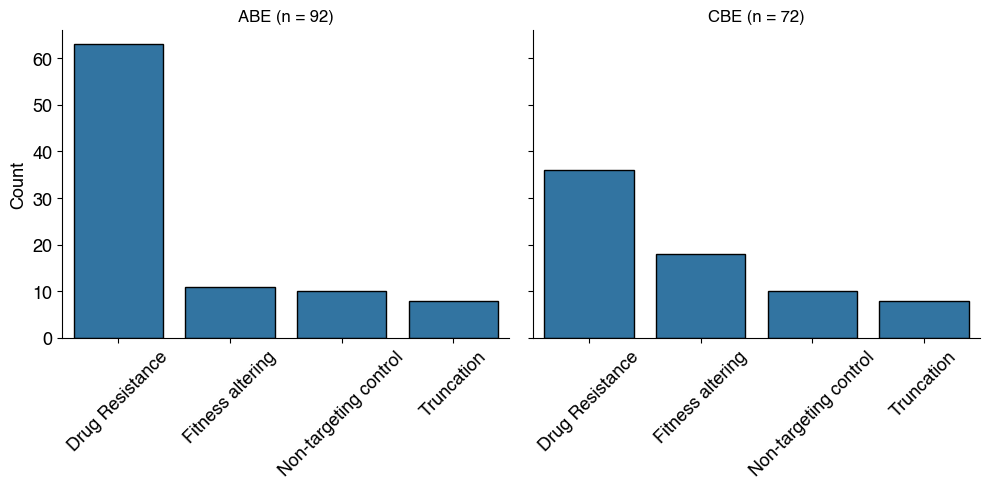

In [658]:
fig, ax = plt.subplots(1,2, figsize=(10,5), sharey=True)
sns.barplot(data=abe_final_final.value_counts('Type').reset_index(), x='Type', y='count', ax=ax[0], edgecolor='black', linewidth=1)
sns.barplot(data=cbe_final_final.value_counts('Type').reset_index(), x='Type', y='count', ax=ax[1], edgecolor='black', linewidth=1)

ax[0].set_title(f'ABE (n = {len(abe_final_final)})')
ax[1].set_title(f'CBE (n = {len(cbe_final_final)})')
ax[0].set_ylabel('Count', fontsize=13)

ax[0].tick_params(axis='x', rotation=45)
ax[1].tick_params(axis='x', rotation=45)
ax[0].spines[['top', 'right']].set_visible(False)
ax[1].spines[['top', 'right']].set_visible(False)
ax[0].tick_params(axis='both', which='major', labelsize=13)
ax[1].tick_params(axis='both', which='major', labelsize=13)

ax[0].set_xlabel('')
ax[1].set_xlabel('')
fig.tight_layout()

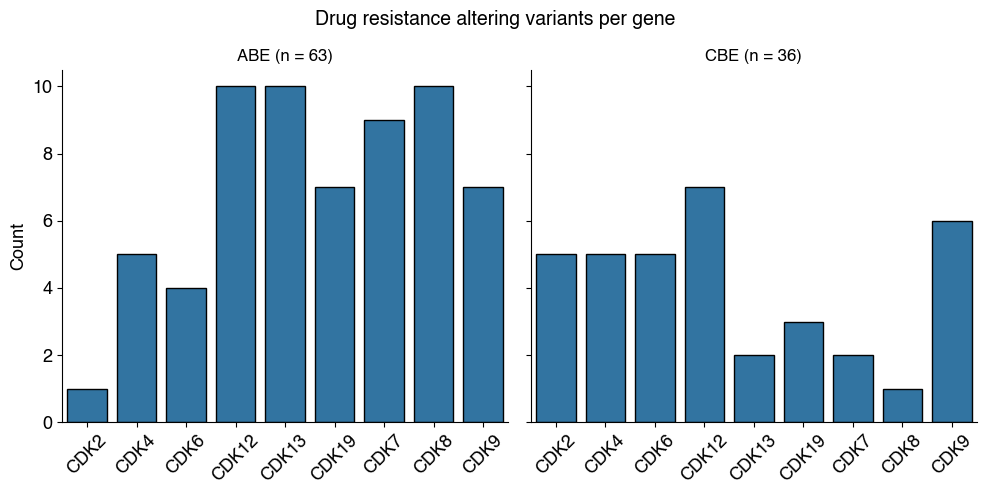

In [659]:
fig, ax = plt.subplots(1,2, figsize=(10,5), sharey=True)
sns.barplot(data=abe_final_final[abe_final_final['Type']=='Drug Resistance'].value_counts('gene').reset_index(), x='gene', y='count', ax=ax[0], edgecolor='black', linewidth=1, order = genes)
sns.barplot(data=cbe_final_final[cbe_final_final['Type']=='Drug Resistance'].value_counts('gene').reset_index(), x='gene', y='count', ax=ax[1], edgecolor='black', linewidth=1, order=genes)

ax[0].set_title(f"ABE (n = {len(abe_final_final[abe_final_final['Type']=='Drug Resistance'])})")
ax[1].set_title(f"CBE (n = {len(cbe_final_final[cbe_final_final['Type']=='Drug Resistance'])})")
ax[0].set_ylabel('Count', fontsize=13)

ax[0].tick_params(axis='x', rotation=45)
ax[1].tick_params(axis='x', rotation=45)
ax[0].spines[['top', 'right']].set_visible(False)
ax[1].spines[['top', 'right']].set_visible(False)
ax[0].tick_params(axis='both', which='major', labelsize=13)
ax[1].tick_params(axis='both', which='major', labelsize=13)

ax[0].set_xlabel('')
ax[1].set_xlabel('')
fig.suptitle('Drug resistance altering variants per gene', fontsize=14)
fig.tight_layout()

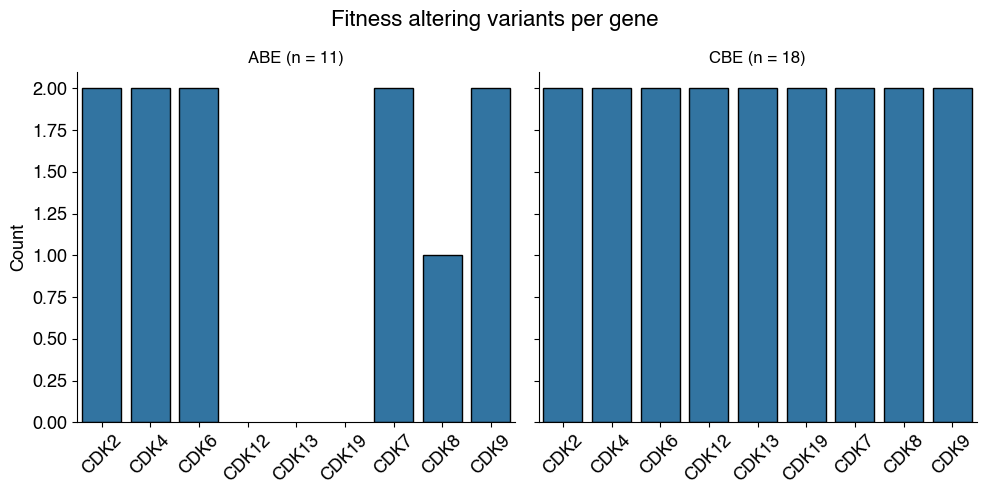

In [660]:
fig, ax = plt.subplots(1,2, figsize=(10,5), sharey=True)
sns.barplot(data=abe_final_final[abe_final_final['Type']=='Fitness altering'].value_counts('gene').reset_index(), x='gene', y='count', ax=ax[0], edgecolor='black', linewidth=1, order = genes)
sns.barplot(data=cbe_final_final[cbe_final_final['Type']=='Fitness altering'].value_counts('gene').reset_index(), x='gene', y='count', ax=ax[1], edgecolor='black', linewidth=1, order=genes)

ax[0].set_title(f"ABE (n = {len(abe_final_final[abe_final_final['Type']=='Fitness altering'])})")
ax[1].set_title(f"CBE (n = {len(cbe_final_final[cbe_final_final['Type']=='Fitness altering'])})")
ax[0].set_ylabel('Count', fontsize=13)

ax[0].tick_params(axis='x', rotation=45)
ax[1].tick_params(axis='x', rotation=45)
ax[0].spines[['top', 'right']].set_visible(False)
ax[1].spines[['top', 'right']].set_visible(False)
ax[0].tick_params(axis='both', which='major', labelsize=13)
ax[1].tick_params(axis='both', which='major', labelsize=13)

ax[0].set_xlabel('')
ax[1].set_xlabel('')
fig.suptitle('Fitness altering variants per gene', fontsize=16)
fig.tight_layout()